# Tacking diagram — interactive plots

Loads pre-computed data from `data/tacking_diagram.npz` and reproduces the
VMP polar and T_cycle polar diagrams.  Edit any cell freely to adjust
formatting, colourmaps, line widths, etc.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Load data

In [3]:
npz_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'data', 'tacking_diagram.npz')
d = np.load(npz_path)

# Phase 1 — V_ref_min per heading
p1_theta   = d['p1_theta']    # radians, shape (n_headings,)
p1_vrefmin = d['p1_vrefmin']  # m/s,     shape (n_headings,)  — NaN for failures

# Phase 2 — original half of the VMP sweep
theta   = d['theta']    # optimisation heading [rad]
V_ref   = d['V_ref']    # wind-shear ref speed [m/s]
N_v     = d['N_v']      # collocation nodes used
u_avg   = d['u_avg']    # mean crosswind velocity [m/s]
v_avg   = d['v_avg']    # mean upwind   velocity [m/s]
speed   = d['speed']    # ground speed  [m/s]
angle   = d['angle']    # actual travel angle [rad, 0=headwind, CW]
T_cycle = d['T_cycle']  # soaring cycle period [s]

print(f"Loaded {len(theta)} primary results from: {npz_path}")
print(f"V_ref range: {V_ref.min():.0f} – {V_ref.max():.0f} m/s")
print(f"Speed range: {speed.min():.1f} – {speed.max():.1f} m/s")
print(f"T_cycle range: {T_cycle.min():.2f} – {T_cycle.max():.2f} s")

Loaded 808 primary results from: /home/kristiancuervo/albatross/refactor/data/tacking_diagram.npz
V_ref range: 9 – 25 m/s
Speed range: 13.2 – 56.5 m/s
T_cycle range: 2.57 – 11.13 s


In [4]:
# Reconstruct mirrored half (u → −u symmetry)
angle_m = np.arctan2(-u_avg, v_avg) % (2 * np.pi)

# Pack into list-of-dicts matching tacking_diagram.py conventions
results  = [{'theta': theta[i], 'V_ref': V_ref[i], 'u_avg': u_avg[i],
              'v_avg': v_avg[i], 'speed': speed[i], 'angle': angle[i],
              'T_cycle': T_cycle[i]} for i in range(len(theta))]

mirrored = [{'theta': theta[i], 'V_ref': V_ref[i], 'u_avg': -u_avg[i],
              'v_avg': v_avg[i], 'speed': speed[i], 'angle': angle_m[i],
              'T_cycle': T_cycle[i]} for i in range(len(theta))]

v_ref_set = sorted(set(V_ref.tolist()))

## Colour map & norm

Change `cmap` or the `vmin`/`vmax` here to restyle both plots at once.

In [5]:
cmap = plt.cm.plasma
norm = Normalize(vmin=min(v_ref_set), vmax=max(v_ref_set))

## VMP polar — iso-V_ref ground-speed curves

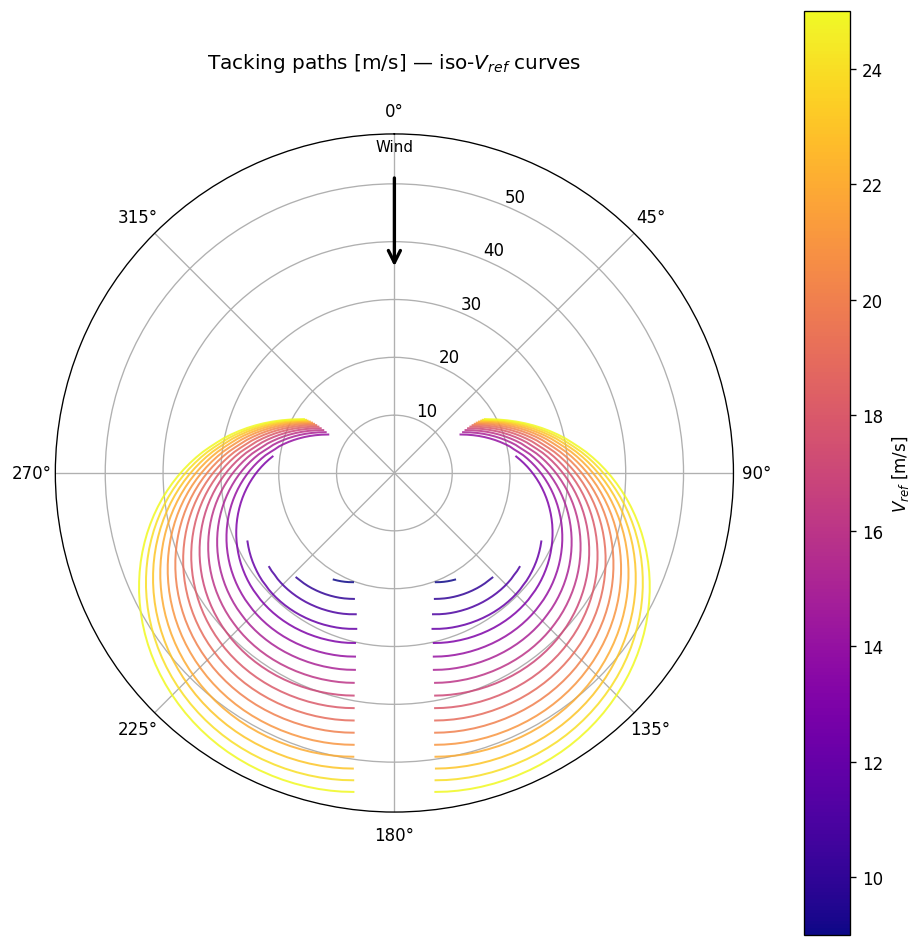

In [6]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))

for v_ref in v_ref_set:
    color = cmap(norm(v_ref))

    pts_o = sorted(
        [(r['angle'], r['speed']) for r in results  if r['V_ref'] == v_ref],
        key=lambda p: p[0]
    )
    pts_m = sorted(
        [(r['angle'], r['speed']) for r in mirrored if r['V_ref'] == v_ref],
        key=lambda p: p[0]
    )

    if len(pts_o) >= 2:
        ao, so = zip(*pts_o)
        ax.plot(ao, so, color=color, lw=1.2, alpha=0.85)
    if len(pts_m) >= 2:
        am, sm = zip(*pts_m)
        ax.plot(am, sm, color=color, lw=1.2, alpha=0.85)

sm_cb = ScalarMappable(cmap=cmap, norm=norm)
sm_cb.set_array([])
plt.colorbar(sm_cb, ax=ax, label='$V_{ref}$ [m/s]', pad=0.08)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_title(r'Tacking paths [m/s] — iso-$V_{ref}$ curves', pad=20)

# Wind direction arrow: points inward at theta=0 (headwind = top of plot)
r_max = ax.get_rmax()
ax.annotate('',
    xy=(0, r_max * 0.60),      # arrowhead (inner)
    xytext=(0, r_max * 0.88),  # tail (outer)
    arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=18),
)
ax.text(0, r_max * 0.94, 'Wind', ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.show()

## T_cycle polar — iso-V_ref cycle-period curves

Polar angle = optimisation heading θ (not actual travel direction).

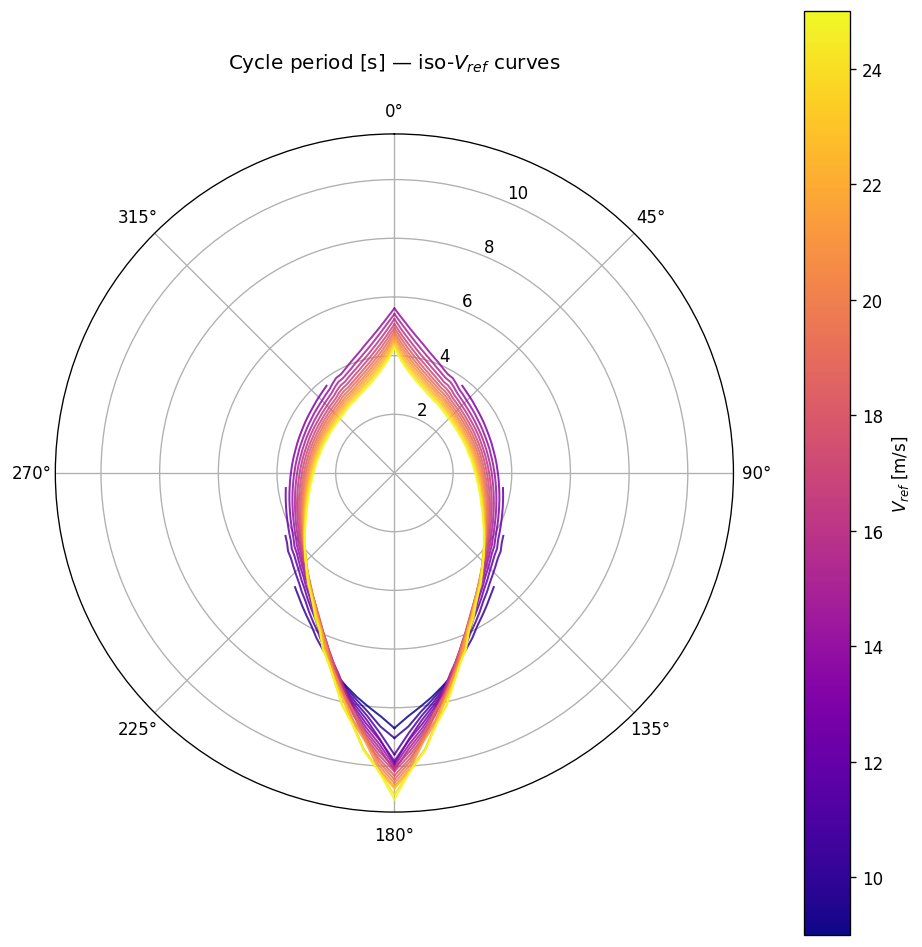

In [7]:
fig2, ax2 = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))

for v_ref in v_ref_set:
    color = cmap(norm(v_ref))

    pts_o = sorted(
        [(r['theta'], r['T_cycle']) for r in results if r['V_ref'] == v_ref],
        key=lambda p: p[0]
    )

    # Mirrored arc: (2π − θ) % 2π maps θ∈[0,π] → angles in [π, 2π] ∪ {0}.
    # Sorting naively puts angle=0 (from θ=0) first, causing a 0→π jump
    # through the centre.  Fix: sort the π…2π portion ascending, then append
    # the θ=0 point (angle=0 ≡ 2π) at the end so the arc closes smoothly.
    raw_m = [((2 * np.pi - r['theta']) % (2 * np.pi), r['T_cycle'])
             for r in results if r['V_ref'] == v_ref]
    right_arc = sorted([(a, t) for a, t in raw_m if a > 1e-9], key=lambda p: p[0])
    close_pt  = [(a, t) for a, t in raw_m if a <= 1e-9]
    pts_m = right_arc + close_pt

    if len(pts_o) >= 2:
        ao, to = zip(*pts_o)
        ax2.plot(ao, to, color=color, lw=1.2, alpha=0.85)
    if len(pts_m) >= 2:
        am, tm = zip(*pts_m)
        ax2.plot(am, tm, color=color, lw=1.2, alpha=0.85)

sm_cb2 = ScalarMappable(cmap=cmap, norm=norm)
sm_cb2.set_array([])
plt.colorbar(sm_cb2, ax=ax2, label='$V_{ref}$ [m/s]', pad=0.08)

ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)
ax2.set_title(r'Cycle period [s] — iso-$V_{ref}$ curves', pad=20)
plt.tight_layout()
plt.show()

## Two-cycle average velocity polar

Each iso-$V_{ref}$ curve shows the **boundary of all average velocities achievable over two consecutive soaring cycles**.

For a single cycle the bird must carry some crosswind component, so the single-cycle arcs avoid $\theta=0°$ (pure headwind) and $\theta=180°$ (pure downwind).  Over two cycles the bird can tack:

* **once right, once left** — crosswind cancels → net velocity points straight upwind ($\theta=0°$, where $v_\text{avg}>0$) or straight downwind ($\theta=180°$, where $v_\text{avg}<0$).

Mathematically, the achievable set is the **convex hull** of the symmetric single-cycle set $\{(u,v)\}\cup\{(-u,v)\}$.  The boundary is traced below by ray–hull intersection for each polar angle.

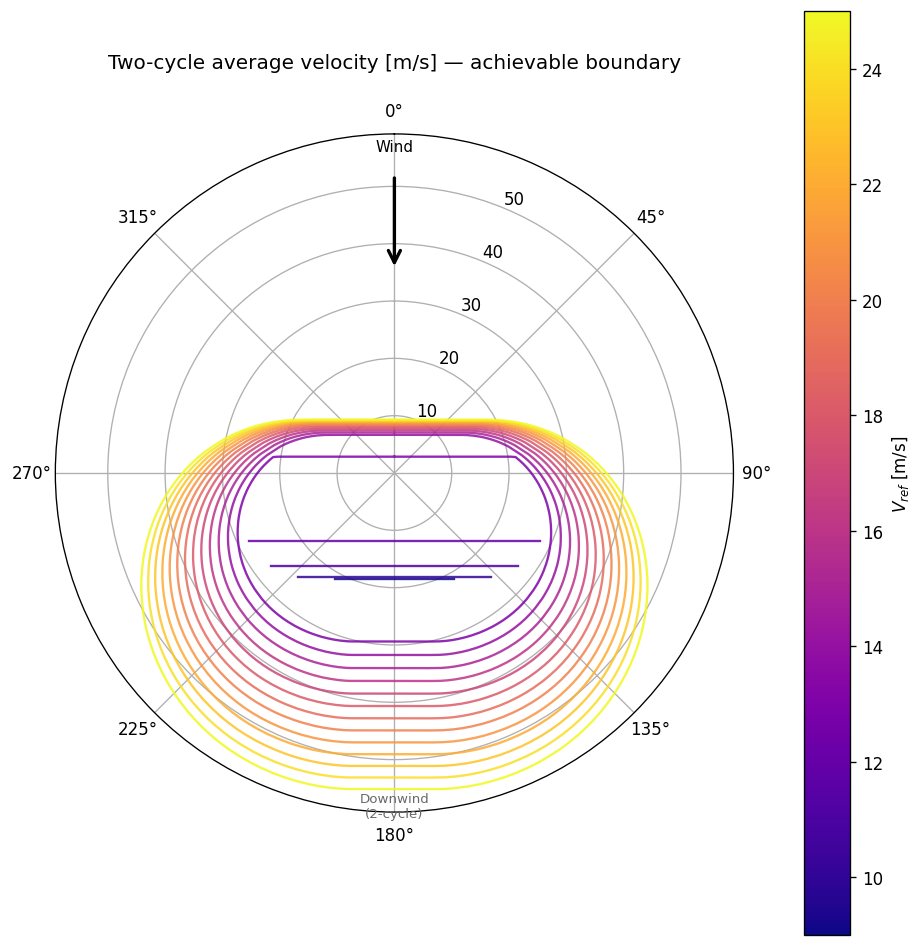

In [8]:
from scipy.spatial import ConvexHull

fig3, ax3 = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))

# Angular resolution for tracing the hull boundary
n_rays = 720
thetas_ray = np.linspace(0, 2 * np.pi, n_rays, endpoint=False)
# Unit direction vectors in (u_cross, v_up) space for each polar angle
# theta=0 → headwind → pure positive-v direction → (sin0, cos0) = (0, 1)
dx_rays = np.sin(thetas_ray)   # crosswind component of each ray
dy_rays = np.cos(thetas_ray)   # upwind    component of each ray

for v_ref in v_ref_set:
    color = cmap(norm(v_ref))

    # All single-cycle velocity vectors for this V_ref (original + mirrored)
    mask = V_ref == v_ref
    uc   = u_avg[mask]
    vc   = v_avg[mask]

    u_all = np.concatenate([ uc, -uc])
    v_all = np.concatenate([ vc,  vc])
    pts   = np.unique(np.column_stack([u_all, v_all]), axis=0)

    if len(pts) < 3:
        continue
    try:
        hull = ConvexHull(pts)
    except Exception:
        continue

    # Build closed edge list for the hull
    hv = pts[hull.vertices]
    hv_closed = np.vstack([hv, hv[0]])   # (n_verts+1, 2)
    n_edges    = len(hv_closed) - 1

    # Vectorised ray–edge intersection
    # Ray: p = t * (dx, dy),  t > 0
    # Edge: q = (x1,y1) + s * (ex,ey),  s ∈ [0,1]
    radii = np.full(n_rays, np.nan)

    for i in range(n_edges):
        x1, y1 = hv_closed[i]
        x2, y2 = hv_closed[i + 1]
        ex, ey = x2 - x1, y2 - y1

        denom = dx_rays * ey - dy_rays * ex          # (n_rays,)
        ok    = np.abs(denom) > 1e-12

        with np.errstate(divide='ignore', invalid='ignore'):
            t = np.where(ok, (x1 * ey - y1 * ex) / denom, np.nan)
            s = np.where(ok, (x1 * dy_rays - y1 * dx_rays) / denom, np.nan)

        valid = ok & (t > 1e-9) & (s >= -1e-9) & (s <= 1 + 1e-9)
        # Keep the *nearest* intersection (outermost hull face from origin)
        update = valid & (np.isnan(radii) | (t < radii))
        radii  = np.where(update, t, radii)

    ax3.plot(thetas_ray, radii, color=color, lw=1.4, alpha=0.85)

sm_cb3 = ScalarMappable(cmap=cmap, norm=norm)
sm_cb3.set_array([])
plt.colorbar(sm_cb3, ax=ax3, label='$V_{ref}$ [m/s]', pad=0.08)

ax3.set_theta_zero_location('N')
ax3.set_theta_direction(-1)
ax3.set_title(r'Two-cycle average velocity [m/s] — achievable boundary', pad=20)

# Annotate the two new cardinal directions
r_max = ax3.get_rmax()
# Headwind arrow (same as VMP polar)
ax3.annotate('',
    xy=(0, r_max * 0.60), xytext=(0, r_max * 0.88),
    arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=18),
)
ax3.text(0, r_max * 0.94, 'Wind', ha='center', va='bottom', fontsize=9, color='black')
# Downwind label
ax3.text(np.pi, r_max * 0.94, 'Downwind\n(2-cycle)', ha='center', va='top',
         fontsize=8, color='dimgray')

plt.tight_layout()
plt.show()